# 03c — KPI Subscriber Segmentation (Dataset 2)
SpiriCom · Huawei Technologies Tunisia · PFE 2026

Produces `data/outputs/kpi_segments.json` for the dashboard's
UserSegments page (Dataset 2 tab), served by the analytics API.

## What this notebook does

Dataset 2 (4,896 KPI subscribers) has continuous network and usage
features — exactly the right shape for KMeans clustering.  We cluster
on **de-imputed QoS features only** (same leak-free set as NB04) so
the segments describe *network experience*, not usage volume which was
already used to define the disengagement label.

| Step | Output |
|------|--------|
| KMeans k=4 on 11 QoS features | Cluster assignments |
| Cluster profiles | Size, disengagement rate, top province, top generation |
| Province × cluster heatmap | Geographic distribution |
| `kpi_segments.json` | Dashboard + API artifact |

> **Source**: `data/processed/churn_labelled_v6.parquet` (all 4,896 rows —
> labelled and unlabelled alike, since segmentation does not need a label).


In [1]:
import pandas as pd
import numpy  as np
import json, warnings, joblib
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing   import StandardScaler
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score
from sklearn.impute           import SimpleImputer
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

PROC_DIR  = Path('data/processed')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
FIG_DIR   = OUT_DIR / 'figures'
for d in [OUT_DIR, FIG_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280', cyan='#22D3EE')
PALETTE = [HW['blue'], HW['red'], HW['green'], HW['amber'],
           HW['purple'], HW['cyan'], '#F97316', '#14B8A6']

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':'#E5E7EB','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'axes.grid.axis':'y','grid.color':'#F3F4F6',
    'axes.labelcolor':HW['navy'],'axes.labelweight':'bold',
    'axes.titlesize':13,'axes.titleweight':'bold','axes.titlecolor':HW['navy'],
    'xtick.color':HW['muted'],'ytick.color':HW['muted'],
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')
print('✅ Setup complete')


✅ Setup complete


---
## §1 — Load & Prepare Data

In [2]:
# §1.1 — Load churn_labelled_v6.parquet (all 4,896 subscribers)
# Use the v6 labelled parquet: it has de-imputed QoS flags (*_imputed)
# that let us restore NaN for genuinely missing values before clustering.
df = None
for p in [PROC_DIR/'churn_labelled_v6.parquet',
          PROC_DIR/'churn_features_v6.parquet']:
    if p.exists():
        df = pd.read_parquet(p)
        df.columns = df.columns.str.lower()
        print(f'Loaded: {p}  ({len(df):,} rows × {df.shape[1]} cols)')
        break
if df is None:
    raise FileNotFoundError(
        'churn_labelled_v6.parquet not found — run NB00→NB03b first')

# §1.2 — De-impute QoS columns (same pattern as NB04 / NB04b)
# Only e2e_delay_ms and client_rtt_ms have *_imputed flags from NB03b;
# their imputed-median values are restored to NaN so cluster means
# are computed on genuinely observed measurements only.
n_deimputed = 0
for base in ['e2e_delay_ms', 'client_rtt_ms']:
    flag = f'{base}_imputed'
    if flag in df.columns:
        n_imp = int((df[flag] == 1).sum())
        df.loc[df[flag] == 1, base] = np.nan
        n_deimputed += n_imp
        print(f'  De-imputed {n_imp:,} rows in {base}')

print(f'Total de-imputed cells: {n_deimputed:,}')

# §1.3 — Identify available columns
PROV_COL = next((c for c in ['layer2name','province','region','governorate', 'gouvernorat','prov', 'gov'] if c in df.columns), None)
GEN_COL  = next((c for c in ['generation','device_generation']  if c in df.columns), None)
CHURN_COL = next((c for c in ['churn', 'is_disengaged', 'disengaged','label', 'target', 'disengagement'] if c in df.columns), None)
print(f'Province col : {PROV_COL}')
print(f'Generation col: {GEN_COL}')
print(f'Churn col present: {"churn" in df.columns}')


Loaded: data\processed\churn_labelled_v6.parquet  (4,896 rows × 34 cols)
  De-imputed 2,071 rows in e2e_delay_ms
  De-imputed 2,091 rows in client_rtt_ms
Total de-imputed cells: 4,162
Province col : layer2name
Generation col: generation
Churn col present: True


---
## §2 — Feature Selection & KMeans

QoS features for clustering (11): ['e2e_delay_ms', 'client_rtt_ms', 'server_rtt_ms', 'client_packet_loss_rate', 'server_packet_loss_rate', 'page_response_delay', 'page_download_throughput', 'dns_delay', 'dns_sr', 'tcp_connection_sr', 'number_of_regions']

Missing values per feature:
  e2e_delay_ms                       : 2,071 NaN  (42.3%)
  client_rtt_ms                      : 2,091 NaN  (42.7%)
  server_rtt_ms                      : 0 NaN  (0.0%)
  client_packet_loss_rate            : 0 NaN  (0.0%)
  server_packet_loss_rate            : 0 NaN  (0.0%)
  page_response_delay                : 0 NaN  (0.0%)
  page_download_throughput           : 0 NaN  (0.0%)
  dns_delay                          : 0 NaN  (0.0%)
  dns_sr                             : 0 NaN  (0.0%)
  tcp_connection_sr                  : 0 NaN  (0.0%)
  number_of_regions                  : 0 NaN  (0.0%)

Feature matrix: 4,896 × 11  (scaled)
  Saved: data\outputs\figures\fig03c_A_elbow_silhouette.png


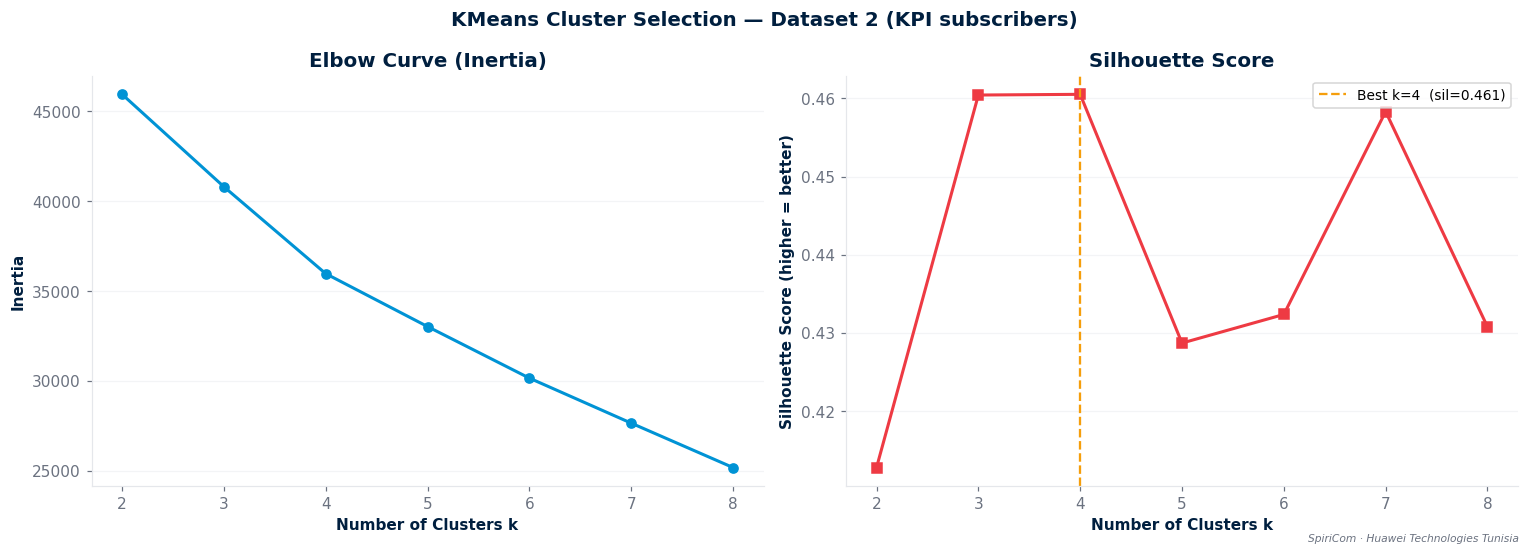


Best k by silhouette: 4  (score=0.4605)


In [3]:
# §2.1 — QoS feature set (leak-free — same candidates as NB04)
# Excludes: dou_total, duration, traffic_* (label derivation inputs),
# *_imputed flags (binary, not QoS), brand/generation (categorical).
QOS_CANDIDATES = [
    'e2e_delay_ms', 'client_rtt_ms', 'server_rtt_ms',
    'client_packet_loss_rate', 'server_packet_loss_rate',
    'page_response_delay', 'page_download_throughput',
    'dns_delay', 'dns_sr', 'tcp_connection_sr', 'number_of_regions',
]
QOS_FEATURES = [c for c in QOS_CANDIDATES if c in df.columns]
print(f'QoS features for clustering ({len(QOS_FEATURES)}): {QOS_FEATURES}')

X_raw = df[QOS_FEATURES].copy()
print(f'\nMissing values per feature:')
for c in QOS_FEATURES:
    n_nan = int(X_raw[c].isna().sum())
    pct   = n_nan / len(X_raw) * 100
    print(f'  {c:<35s}: {n_nan:,} NaN  ({pct:.1f}%)')

# §2.2 — Impute remaining NaN with column median before clustering
# (NaN values are legitimate "no telemetry" signals; median imputation
#  is the standard KMeans preprocessing step. The cluster that captures
#  "missing-telemetry" subscribers should emerge naturally via the
#  median values pulling those rows together.)
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X_raw)
X_imp = pd.DataFrame(X_imp, columns=QOS_FEATURES, index=df.index)

# §2.3 — Standardise (KMeans is distance-based → must scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
print(f'\nFeature matrix: {X_scaled.shape[0]:,} × {X_scaled.shape[1]}  (scaled)')

# §2.4 — Elbow + silhouette to choose k
K_RANGE   = range(2, 9)
inertias  = []
sil_scores = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KMeans Cluster Selection — Dataset 2 (KPI subscribers)',
             fontsize=13, fontweight='bold', color=HW['navy'])
axes[0].plot(list(K_RANGE), inertias, 'o-', color=HW['blue'], lw=2)
axes[0].set_title('Elbow Curve (Inertia)')
axes[0].set_xlabel('Number of Clusters k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_RANGE), sil_scores, 's-', color=HW['red'], lw=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters k')
axes[1].set_ylabel('Silhouette Score (higher = better)')
best_k = int(np.argmax(sil_scores)) + 2   # K_RANGE starts at 2
axes[1].axvline(best_k, ls='--', color=HW['amber'], lw=1.5,
                label=f'Best k={best_k}  (sil={max(sil_scores):.3f})')
axes[1].legend(fontsize=9)
wm(fig); plt.tight_layout()
save_fig('fig03c_A_elbow_silhouette')
plt.show()
print(f'\nBest k by silhouette: {best_k}  (score={max(sil_scores):.4f})')


In [4]:
# §2.5 — Fit final KMeans with chosen k
# Hard-cap at 5 so the dashboard legend stays readable;
# override best_k if silhouette is nearly flat above k=4.
K_FINAL = min(best_k, 5)
print(f'Using K_FINAL = {K_FINAL}  (capped at 5 for dashboard readability)')

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['cluster'] = km_final.fit_predict(X_scaled)

# Save model + scaler for future inference
joblib.dump(km_final, MODEL_DIR / 'kpi_kmeans.pkl')
joblib.dump(scaler,   MODEL_DIR / 'kpi_scaler.pkl')
joblib.dump(imp,      MODEL_DIR / 'kpi_imputer.pkl')
joblib.dump(QOS_FEATURES, MODEL_DIR / 'kpi_cluster_features.pkl')
print(f'Models saved to {MODEL_DIR}/')

# Cluster sizes
sizes = df['cluster'].value_counts().sort_index()
print(f'\nCluster sizes:')
for cid, n in sizes.items():
    bar = '█' * int(n / len(df) * 40)
    print(f'  Cluster {cid}: {n:5,}  ({n/len(df)*100:.1f}%)  {bar}')

sil_final = silhouette_score(X_scaled, df['cluster'], random_state=42)
print(f'\nFinal silhouette score (k={K_FINAL}): {sil_final:.4f}')


Using K_FINAL = 4  (capped at 5 for dashboard readability)
Models saved to models/

Cluster sizes:
  Cluster 0:   441  (9.0%)  ███
  Cluster 1:   728  (14.9%)  █████
  Cluster 2:     1  (0.0%)  
  Cluster 3: 3,726  (76.1%)  ██████████████████████████████

Final silhouette score (k=4): 0.4539


---
## §3 — Cluster Profiles

In [5]:
# §3.1 — Profile each cluster on QoS means + disengagement rate
profiles = []
total = len(df)

for cid in sorted(df['cluster'].unique()):
    grp = df[df['cluster'] == cid]
    p = {
        'cluster_id':    int(cid),
        'n_users':       int(len(grp)),
        'pct':           round(len(grp) / total * 100, 1),
    }
    # QoS means (NaN-aware — only observed values)
    for feat in QOS_FEATURES:
        v = grp[feat].mean()
        p[f'avg_{feat}'] = round(float(v), 4) if pd.notna(v) else None

    # Disengagement rate (labelled population only)
    if CHURN_COL and CHURN_COL in grp.columns:
        lab = grp[CHURN_COL].dropna()
        p['disengagement_rate'] = round(float(lab.mean()) * 100, 1) if len(lab) else None
        p['n_labelled']         = int(len(lab))

    # Top province
    if PROV_COL and PROV_COL in grp.columns:
        prov_vc = grp[PROV_COL].dropna().value_counts()
        if len(prov_vc):
            p['top_province']     = str(prov_vc.index[0])
            p['top_province_pct'] = round(prov_vc.iloc[0] / len(grp) * 100, 1)

    # Dominant generation
    if GEN_COL and GEN_COL in grp.columns:
        gen_vc = grp[GEN_COL].dropna().value_counts()
        if len(gen_vc):
            p['top_generation'] = str(gen_vc.index[0])

    # Auto-label: combine QoS profile into a human-readable name
    avg_delay = p.get('avg_e2e_delay_ms')
    avg_pkt   = p.get('avg_server_packet_loss_rate')
    diseng    = p.get('disengagement_rate')
    if avg_delay is None:
        label = f'Cluster {cid} — No Telemetry'
    elif avg_delay > 350:
        label = f'Cluster {cid} — High Latency'
    elif avg_pkt is not None and avg_pkt > 0.003:
        label = f'Cluster {cid} — High Packet Loss'
    elif diseng is not None and diseng > 45:
        label = f'Cluster {cid} — At-Risk'
    else:
        label = f'Cluster {cid} — Good QoS'
    p['cluster_label'] = label
    profiles.append(p)

print(f'Profiles: {len(profiles)} clusters\n')
print(f'{"Cluster":<30s} {"N":>6}  {"Pct":>5}  {"Diseng":>7}  {"AvgDelay":>9}  Top Province')
print('─' * 85)
for p in profiles:
    dis = f'{p["disengagement_rate"]:>6.1f}%' if p.get('disengagement_rate') is not None else '     —'
    dly = f'{p["avg_e2e_delay_ms"]:>8.0f}ms' if p.get('avg_e2e_delay_ms') is not None else '        —'
    print(f'{p["cluster_label"]:<30s} {p["n_users"]:>6,}  {p["pct"]:>4.1f}%  {dis}  {dly}  '
          f'{p.get("top_province","—")} ({p.get("top_province_pct",0):.0f}%)')


Profiles: 4 clusters

Cluster                             N    Pct   Diseng   AvgDelay  Top Province
─────────────────────────────────────────────────────────────────────────────────────
Cluster 0 — High Latency          441   9.0%    27.5%       952ms  KASSERINE (10%)
Cluster 1 — At-Risk               728  14.9%    95.7%       178ms  TUNIS (20%)
Cluster 2 — High Packet Loss        1   0.0%       —       289ms  TUNIS (100%)
Cluster 3 — Good QoS            3,726  76.1%    24.4%       207ms  TUNIS (17%)


---
## §4 — Visualisations

  Saved: data\outputs\figures\fig03c_B_cluster_qos_heatmap.png


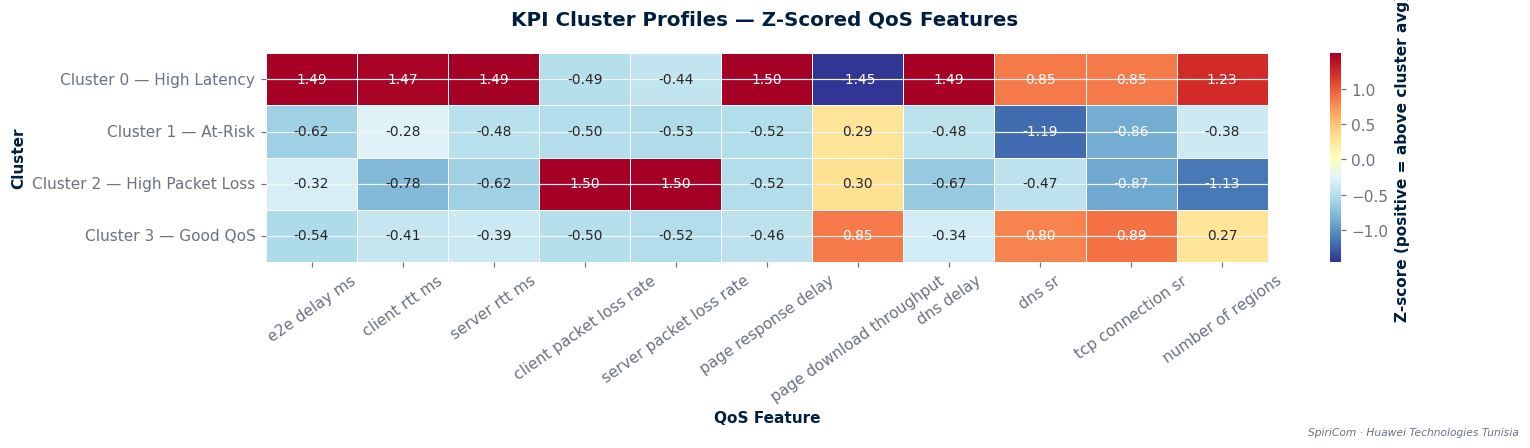

  Saved: data\outputs\figures\fig03c_C_cluster_disengagement.png


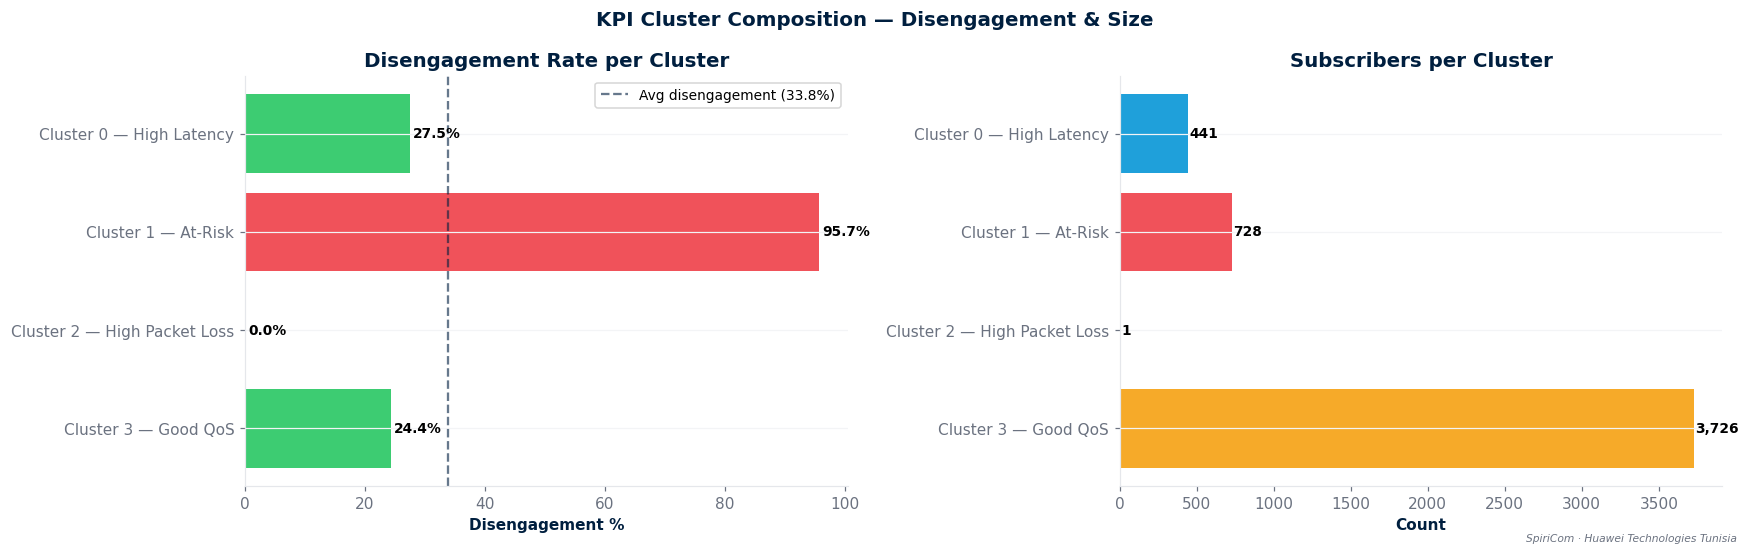

In [6]:
# §4.1 — QoS feature means per cluster (heatmap)
qos_means = pd.DataFrame(
    [[p.get(f'avg_{f}') for f in QOS_FEATURES] for p in profiles],
    index=[p['cluster_label'] for p in profiles],
    columns=[f.replace('_',' ') for f in QOS_FEATURES]
)
# Z-score each column for heatmap readability
qos_z = (qos_means - qos_means.mean()) / (qos_means.std() + 1e-9)

fig, ax = plt.subplots(figsize=(max(14, len(QOS_FEATURES)*1.2), 4))
fig.suptitle('KPI Cluster Profiles — Z-Scored QoS Features',
             fontsize=13, fontweight='bold', color=HW['navy'])
sns.heatmap(qos_z, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, linewidths=0.4, annot_kws={'size': 9},
            cbar_kws={'label': 'Z-score (positive = above cluster avg)'})
ax.set_xlabel('QoS Feature')
ax.set_ylabel('Cluster')
ax.tick_params(axis='x', rotation=35)
wm(fig); plt.tight_layout()
save_fig('fig03c_B_cluster_qos_heatmap')
plt.show()

# §4.2 — Disengagement rate per cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('KPI Cluster Composition — Disengagement & Size',
             fontsize=13, fontweight='bold', color=HW['navy'])

ax = axes[0]
labels = [p['cluster_label'] for p in profiles]
dis_rates = [p.get('disengagement_rate', 0) or 0 for p in profiles]
bar_colors = [HW['red'] if d > 40 else HW['amber'] if d > 30 else HW['green']
              for d in dis_rates]
bars = ax.barh(labels[::-1], dis_rates[::-1], color=bar_colors[::-1], alpha=0.88)
for bar, val in zip(bars, dis_rates[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(33.8, ls='--', color=HW['navy'], lw=1.5, alpha=0.6,
           label='Avg disengagement (33.8%)')
ax.set_title('Disengagement Rate per Cluster')
ax.set_xlabel('Disengagement %')
ax.legend(fontsize=9)

ax = axes[1]
sizes_list = [p['n_users'] for p in profiles]
colors = PALETTE[:len(profiles)]
bars = ax.barh(labels[::-1], sizes_list[::-1], color=colors[::-1], alpha=0.88)
for bar, val in zip(bars, sizes_list[::-1]):
    ax.text(val + total*0.002, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Subscribers per Cluster')
ax.set_xlabel('Count')

wm(fig); plt.tight_layout()
save_fig('fig03c_C_cluster_disengagement')
plt.show()


  Saved: data\outputs\figures\fig03c_D_province_cluster_heatmap.png


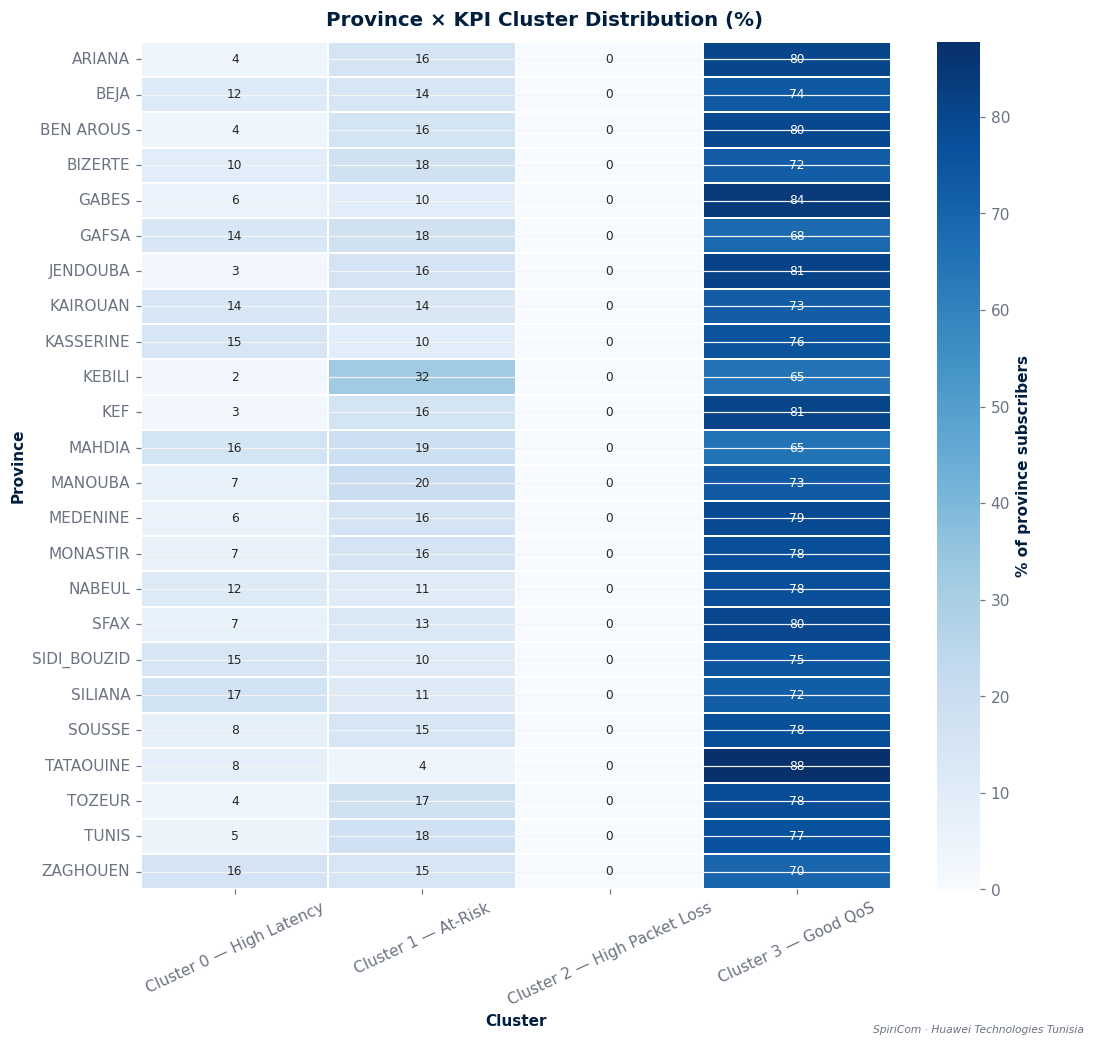

Province distribution built: 24 provinces


In [7]:
# §4.3 — Province × Cluster heatmap
province_dist = []
cross_pct     = pd.DataFrame()

if PROV_COL and PROV_COL in df.columns:
    cross = pd.crosstab(df[PROV_COL], df['cluster'], normalize='index')
    cross_pct = (cross * 100).round(1)
    cross_pct.columns = [profiles[c]['cluster_label'] for c in cross_pct.columns]

    # Heatmap
    fig, ax = plt.subplots(figsize=(max(10, K_FINAL*2), max(8, len(cross_pct)*0.4)))
    fig.suptitle('Province × KPI Cluster Distribution (%)',
                 fontsize=13, fontweight='bold', color=HW['navy'])
    sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='Blues',
                ax=ax, linewidths=0.3, annot_kws={'size': 8},
                cbar_kws={'label': '% of province subscribers'})
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Province')
    ax.tick_params(axis='x', rotation=25)
    wm(fig); plt.tight_layout()
    save_fig('fig03c_D_province_cluster_heatmap')
    plt.show()

    # Build JSON province_distribution — label keys (not cluster_X integers)
    for prov, row in cross_pct.iterrows():
        entry = {'region': str(prov)}
        for label in cross_pct.columns:
            entry[label] = float(row[label])
        province_dist.append(entry)
    print(f'Province distribution built: {len(province_dist)} provinces')
else:
    print(f'⚠ No province column found ({PROV_COL}) — skipping heatmap')


---
## §5 — Save `kpi_segments.json`

In [8]:
# §5.1 — Assemble and save kpi_segments.json
out = {
    'generated_at'       : datetime.now().isoformat(),
    'dataset'            : 'Dataset 2 — churn_labelled_v6.parquet (KPI subscribers)',
    'method'             : f'KMeans k={K_FINAL} · StandardScaler · QoS features only',
    'n_clusters'         : K_FINAL,
    'n_subscribers'      : total,
    'silhouette_score'   : round(sil_final, 4),
    'qos_features'       : QOS_FEATURES,
    'profiles'           : profiles,
    'province_distribution': province_dist,
    # Label map for back-compat — province_distribution uses label keys directly
    'cluster_labels'     : {f'cluster_{p["cluster_id"]}': p['cluster_label']
                            for p in profiles},
    'artifacts'          : {
        'model'    : str(MODEL_DIR / 'kpi_kmeans.pkl'),
        'scaler'   : str(MODEL_DIR / 'kpi_scaler.pkl'),
        'imputer'  : str(MODEL_DIR / 'kpi_imputer.pkl'),
        'features' : str(MODEL_DIR / 'kpi_cluster_features.pkl'),
    },
}

out_path = OUT_DIR / 'kpi_segments.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=str)
print(f'✅  kpi_segments.json  →  {out_path}')

figs = sorted(FIG_DIR.glob('fig03c_*.png'))
print('\n' + '═'*58)
print('NB03c — KPI SUBSCRIBER SEGMENTATION COMPLETE (Dataset 2)')
print('═'*58)
print(f'  Method    : KMeans  k={K_FINAL}  ·  {len(QOS_FEATURES)} QoS features')
print(f'  Silhouette: {sil_final:.4f}')
print(f'  Clusters  : {K_FINAL}  ·  {total:,} subscribers')
print()
print('  Cluster summary:')
for p in profiles:
    dis = f', diseng={p["disengagement_rate"]:.0f}%' if p.get('disengagement_rate') else ''
    print(f'    [{p["cluster_id"]}] {p["cluster_label"]:<32s}: '
          f'{p["n_users"]:,} ({p["pct"]}%{dis})')
print()
print(f'  Figures ({len(figs)}):')
for fp in figs:
    print(f'    {fp.name}')
print()
print('  Dashboard: UserSegments → Dataset 2 tab  ✅')
print('  API reads: kpi_segments.json + kpi_kmeans.pkl')


✅  kpi_segments.json  →  data\outputs\kpi_segments.json

══════════════════════════════════════════════════════════
NB03c — KPI SUBSCRIBER SEGMENTATION COMPLETE (Dataset 2)
══════════════════════════════════════════════════════════
  Method    : KMeans  k=4  ·  11 QoS features
  Silhouette: 0.4539
  Clusters  : 4  ·  4,896 subscribers

  Cluster summary:
    [0] Cluster 0 — High Latency        : 441 (9.0%, diseng=28%)
    [1] Cluster 1 — At-Risk             : 728 (14.9%, diseng=96%)
    [2] Cluster 2 — High Packet Loss    : 1 (0.0%)
    [3] Cluster 3 — Good QoS            : 3,726 (76.1%, diseng=24%)

  Figures (4):
    fig03c_A_elbow_silhouette.png
    fig03c_B_cluster_qos_heatmap.png
    fig03c_C_cluster_disengagement.png
    fig03c_D_province_cluster_heatmap.png

  Dashboard: UserSegments → Dataset 2 tab  ✅
  API reads: kpi_segments.json + kpi_kmeans.pkl
